# SMS Spam Collection — EDA and Model Evaluation

## Team
- Edwin Gómez
- Johan Sebastián Bonilla

## Goal
This notebook performs:
1. **Exploratory Data Analysis (EDA)** on the **SMS Spam Collection** dataset.
2. **Evaluation of the Hugging Face model** `Goodmotion/spam-mail-classifier` on a **random sample of 20 SMS messages**.

> **Important note:** the selected model is a generic spam classifier hosted on Hugging Face. Since it was not necessarily trained specifically on the SMS Spam Collection dataset, this evaluation should be considered **exploratory**.


## Dataset files used in this notebook
- Dataset file: `/mnt/data/SMSSpamCollection`
- Readme file: `/mnt/data/readme`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from transformers import pipeline

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 200)

## 1. Load dataset

In [5]:
# Dataset: SMS Spam Collection from https://archive.ics.uci.edu/dataset/228/sms+spam+collection
dataset_path = r"../data/SMSSpamCollection"
df = pd.read_csv(dataset_path, sep="\t", header=None, names=["label", "message"])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [6]:
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())
print("\nMissing values:")
print(df.isna().sum())

Shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


## 2. Basic preprocessing and feature engineering

In [7]:
df["message"] = df["message"].astype(str)
df["char_length"] = df["message"].str.len()
df["word_count"] = df["message"].str.split().str.len()
df["digit_count"] = df["message"].str.count(r"\d")
df["uppercase_count"] = df["message"].apply(lambda x: sum(1 for c in x if c.isupper()))
df["exclamation_count"] = df["message"].str.count("!")
df["has_url"] = df["message"].str.contains(r"http|www\.|\.com|\.co|\.uk", case=False, regex=True)

df.head()

,label,message,char_length,word_count,digit_count,uppercase_count,exclamation_count,has_url
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,20,0,3,0,False
1,ham,Ok lar... Joking wif u oni...,29,6,0,2,0,False
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,28,25,10,0,False
3,ham,U dun say so early hor... U c already then say...,49,11,0,2,0,False
4,ham,"Nah I don't think he goes to usf, he lives around here though",61,13,0,2,0,False


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class distribution

label
ham     4825
spam     747
Name: count, dtype: int64

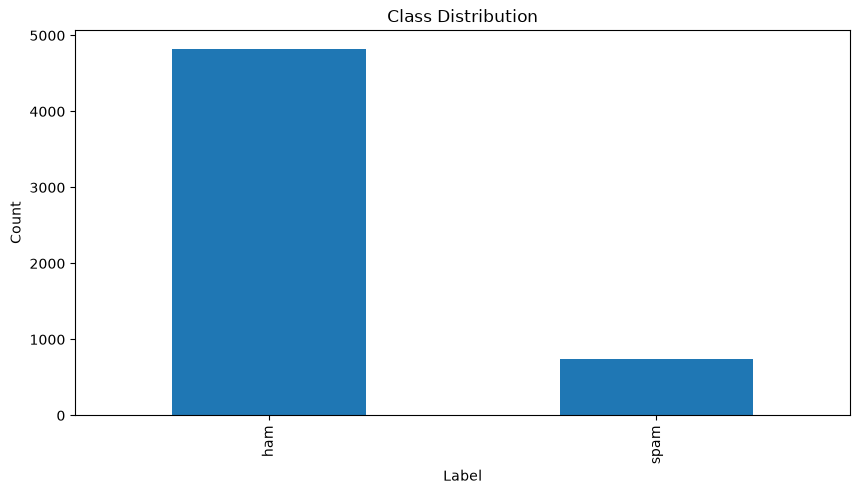

In [8]:
class_counts = df["label"].value_counts()
display(class_counts)

ax = class_counts.plot(kind="bar", title="Class Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.show()

### 3.2 Character length by class

In [9]:
df.groupby("label")["char_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


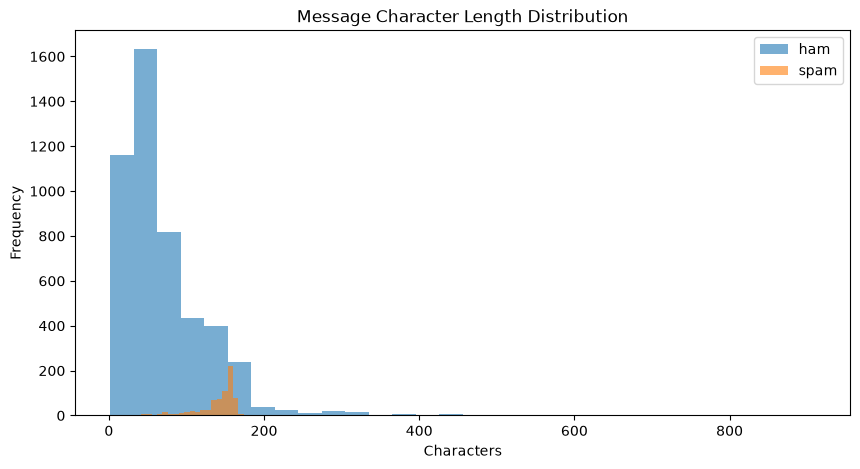

In [10]:
for label in df["label"].unique():
    df[df["label"] == label]["char_length"].plot(kind="hist", alpha=0.6, bins=30, label=label)
plt.title("Message Character Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 3.3 Word count by class

In [11]:
df.groupby("label")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,14.310259,11.517945,1.0,7.0,11.0,19.0,171.0
spam,747.0,23.911647,5.780174,2.0,22.0,25.0,28.0,35.0


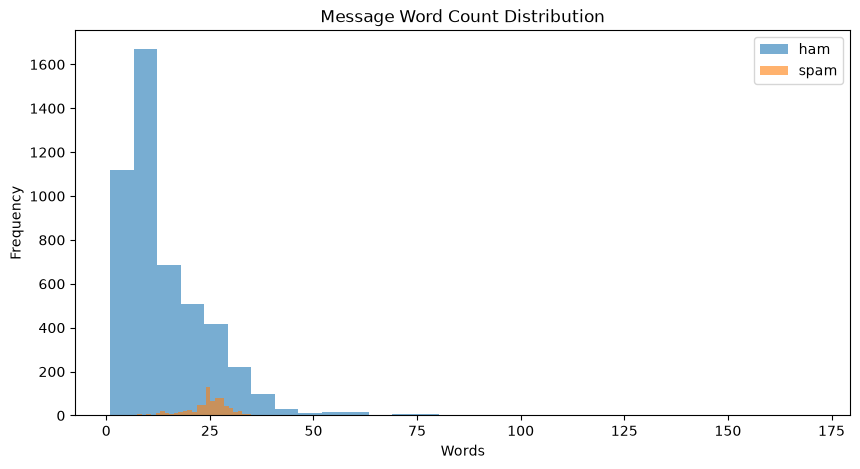

In [12]:
for label in df["label"].unique():
    df[df["label"] == label]["word_count"].plot(kind="hist", alpha=0.6, bins=30, label=label)
plt.title("Message Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 3.4 Additional text features

In [13]:
feature_summary = df.groupby("label")[[
    "digit_count", "uppercase_count", "exclamation_count", "has_url"
]].mean()

feature_summary

,digit_count,uppercase_count,exclamation_count,has_url
label,,,,
ham,0.305285,4.110466,0.176580,0.004145
spam,15.812584,15.469880,0.729585,0.182062


Interpretation hints:
- **digit_count**: spam often contains prices, phone numbers, or codes.
- **uppercase_count**: spam messages frequently use uppercase words to attract attention.
- **exclamation_count**: spam may rely on urgency and exaggerated punctuation.
- **has_url**: spam frequently contains links or website references.


### 3.5 Most common words in ham vs spam

In [14]:
STOPWORDS = {
    "the","a","an","and","or","to","of","in","on","for","is","it","i","im","i'm","you","u",
    "me","my","we","our","your","be","are","am","at","this","that","with","so","but","if",
    "was","were","have","has","had","do","did","will","would","can","could","not","from",
    "as","by","he","she","they","them","his","her","their","us"
}

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"[a-zA-Z']+", text)
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

ham_tokens = []
spam_tokens = []

for _, row in df.iterrows():
    toks = tokenize(row["message"])
    if row["label"] == "ham":
        ham_tokens.extend(toks)
    else:
        spam_tokens.extend(toks)

ham_top = Counter(ham_tokens).most_common(20)
spam_top = Counter(spam_tokens).most_common(20)

ham_top_df = pd.DataFrame(ham_top, columns=["word", "count"])
spam_top_df = pd.DataFrame(spam_top, columns=["word", "count"])

print("Top words in HAM:")
display(ham_top_df)

print("Top words in SPAM:")
display(spam_top_df)

Top words in HAM:


,word,count
0,gt,318
1,lt,316
2,get,311
3,now,300
4,no,299
5,just,297
6,up,290
7,when,284
8,ok,283
9,how,274


Top words in SPAM:


,word,count
0,call,370
1,free,228
2,now,203
3,txt,170
4,ur,144
5,mobile,129
6,stop,128
7,text,126
8,claim,113
9,reply,104


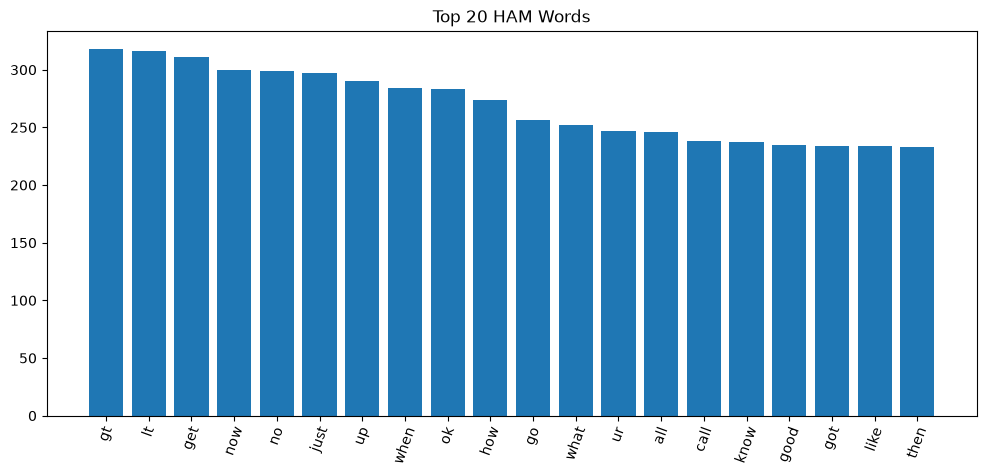

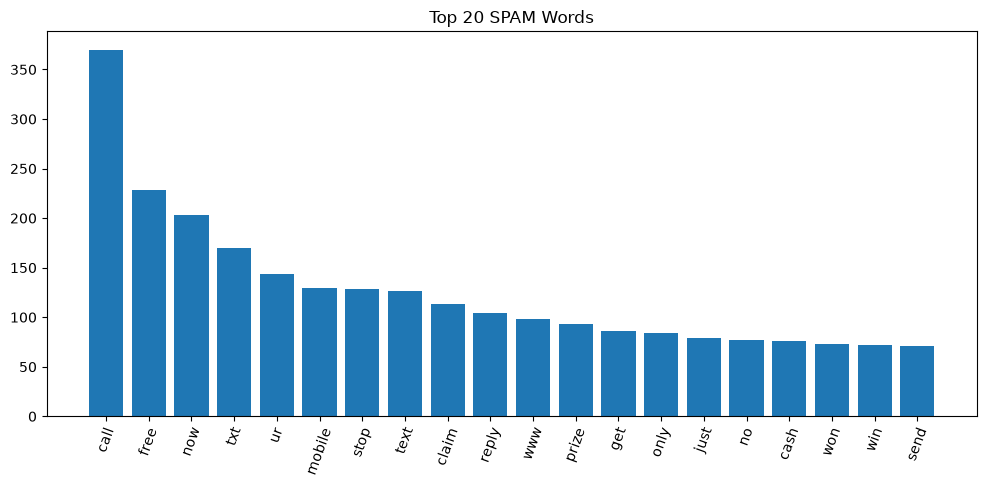

In [15]:
plt.figure(figsize=(12,5))
plt.bar(ham_top_df["word"], ham_top_df["count"])
plt.xticks(rotation=70)
plt.title("Top 20 HAM Words")
plt.show()

plt.figure(figsize=(12,5))
plt.bar(spam_top_df["word"], spam_top_df["count"])
plt.xticks(rotation=70)
plt.title("Top 20 SPAM Words")
plt.show()

## 4. EDA conclusions

Typical patterns often observed in this dataset:
- **Ham** messages are much more frequent than spam messages.
- **Spam** messages tend to be longer and may contain more promotional language.
- Spam messages often include:
  - numbers
  - URLs / references to websites
  - uppercase words
  - exclamation marks
- Frequent spam words usually include terms related to:
  - prizes
  - free offers
  - claim / call / text
  - cash or rewards


## 5. Load Hugging Face model

In [16]:
classifier = pipeline(
    "text-classification",
    model="Goodmotion/spam-mail-classifier"
)
print("Model loaded successfully.")

config.json:   0%|          | 0.00/769 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Model loaded successfully.


## 6. Random sample of 20 messages for testing

For each sampled message we will show:
- the **true label**
- the **predicted label**
- the **confidence score** returned by the model
- whether the prediction was correct


In [ ]:
sample_df = df.sample(20, random_state=42).copy()
sample_df = sample_df.reset_index(drop=True)
sample_df[["label", "message"]].head()

In [ ]:
def normalize_prediction(raw_label: str) -> str:
    label = str(raw_label).lower()
    if "spam" in label:
        return "spam"
    if "ham" in label:
        return "ham"
    # fallback if the model uses generic labels such as LABEL_0 / LABEL_1
    return label

predicted_labels = []
scores = []
correct_flags = []

for msg, true_label in zip(sample_df["message"], sample_df["label"]):
    result = classifier(msg)[0]
    pred_label = normalize_prediction(result["label"])
    score = float(result["score"])

    predicted_labels.append(pred_label)
    scores.append(score)
    correct_flags.append(pred_label == true_label)

sample_df["predicted_label"] = predicted_labels
sample_df["confidence_score"] = scores
sample_df["correct"] = correct_flags

sample_df[["label", "predicted_label", "confidence_score", "correct", "message"]]

### About “precision of each result”
In this notebook, the per-message value reported is the **confidence score** returned by the model for the predicted class.

A formal **precision metric** is computed over the whole sample, not for a single row. Therefore:
- **confidence_score** = per-message confidence of the prediction
- **precision** = global metric computed after evaluating all 20 samples


## 7. Evaluation metrics on the 20-message sample

In [ ]:
y_true = sample_df["label"].tolist()
y_pred = sample_df["predicted_label"].tolist()

accuracy = accuracy_score(y_true, y_pred)
precision_spam = precision_score(y_true, y_pred, pos_label="spam", zero_division=0)
recall_spam = recall_score(y_true, y_pred, pos_label="spam", zero_division=0)
f1_spam = f1_score(y_true, y_pred, pos_label="spam", zero_division=0)

metrics_df = pd.DataFrame({
    "metric": ["accuracy", "precision_spam", "recall_spam", "f1_spam"],
    "value": [accuracy, precision_spam, recall_spam, f1_spam]
})
metrics_df

In [ ]:
print(classification_report(y_true, y_pred, zero_division=0))

## 8. Final remarks

### Main takeaways
1. The **SMS Spam Collection** dataset is highly useful for binary text classification experiments.
2. Spam messages usually show stronger lexical signals such as promotional vocabulary, urgency, numbers, and links.
3. The Hugging Face model can be used as a practical inference layer for quick testing, but the results should be interpreted carefully because the model was not necessarily trained on this exact dataset.

### Limitations
- Only **20 random messages** were used for the evaluation requested in this assignment.
- The model may have **domain mismatch** with SMS-specific language.
- The first execution may require downloading model weights from Hugging Face.

### Suggested next steps
- Evaluate the model on the **full dataset**.
- Build a **confusion matrix** over a larger test set.
- Compare the Hugging Face model against a custom baseline such as:
  - TF-IDF + Logistic Regression
  - TF-IDF + Naive Bayes
  - DistilBERT fine-tuned on SMS Spam Collection
